COLLECTING DATA

In [1]:
import pandas as pd
import glob
import os

files = glob.glob("./data/*.json")
dfs = []

for f in files:
    temp = pd.read_json(f, lines=True)
    temp['category'] = os.path.basename(f).replace("_small.json", "")  # extracts category name
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

print(df.shape)
print(df['category'].value_counts())

(5000, 10)
category
Books          1000
Clothing       1000
Electronics    1000
Grocery        1000
Patio          1000
Name: count, dtype: int64


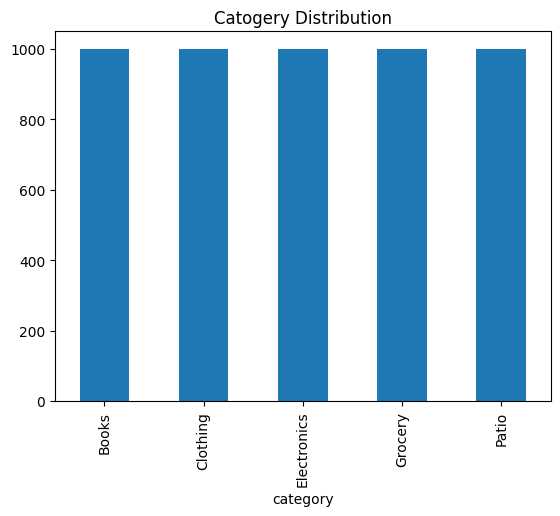

count     5000.000000
mean       493.659800
std        663.228034
min          4.000000
25%        157.000000
50%        278.500000
75%        566.250000
max      11908.000000
Name: length, dtype: float64


In [2]:
import matplotlib.pyplot as plt

df['category'].value_counts().plot(kind='bar')
plt.title("Catogery Distribution")
plt.show()

df['length'] = df['reviewText'].apply(len)
print(df['length'].describe())

NOW WE ARE PERFORMING DATA CLEANING AS THE DATA IS BALANCED

In [3]:
import re 
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer


nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()


def clean_text(text):
    text = text.lower()                           #lowercase
    text = re.sub(r'<.*?>', '', text)             #remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)       #remove punctuations and numbers
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]   #remove stopwords
    tokens = [stemmer.stem(w) for w in tokens]            #stemming
    return ' '.join(tokens)

df['clean_review'] = df['reviewText'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Nidhu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


VECTORIZATION

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10000)
X = vectorizer.fit_transform(df['clean_review'])
y = df['category']

print(X.shape)

(5000, 10000)


SPLITTING DATA

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

MODEL SELECTION AND TRAINING OF MODEL

In [14]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_model_preds = lr_model.predict(X_test)

print("Trianing Done")

Trianing Done


In [26]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_model_preds = dt_model.predict(X_test)

print("Training Done")

Training Done


In [27]:
from sklearn.svm import SVC

svm_model = SVC()
svm_model.fit(X_train,y_train)
svm_model_preds = svm_model.predict(X_test)

print("Trianing Done")

Trianing Done


EVALUATION OF THE MODELS

In [30]:
from sklearn.metrics import accuracy_score, f1_score 

print("LogisticRegression")
print("Accuracy -",accuracy_score(lr_model_preds, y_test))

print("\nDecision Tree")
print("Accuracy -", accuracy_score(dt_model_preds, y_test))

print("\nSVM")
print("Accuracy -", accuracy_score(svm_model_preds, y_test))



LogisticRegression
Accuracy - 0.9353333333333333

Decision Tree
Accuracy - 0.7333333333333333

SVM
Accuracy - 0.93


TESTING OF THE MODEL

In [38]:
def predict_category(text):
    clean = clean_text(text)
    vector = vectorizer.transform([clean])
    return lr_model.predict(vector)[0]


print(predict_category("The garden hose is perfect for watering my plants and lawn"))
     

Patio


SAVING THE MODEL

In [39]:
import joblib

joblib.dump(lr_model, "category_model.pkl")
joblib.dump(vectorizer, "category_vectorizer.pkl")

print("Models Saved!")

Models Saved!


✅ Loaded data

✅ Created labels

✅ Cleaned text

✅ TF-IDF

✅ Train/Test split

✅ Trained 3 models

✅ Evaluated & picked best

✅ Saved model